In [4]:
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
cluster_df = pd.read_csv("../../data/master_data/2016_to_2023_clustering_input_data.csv")

len(cluster_df)

85659

In [6]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab2_POP",
                "Educ6",
                "NSSEC5",
                "IMD10",
                "WorkStat8",
                "Child4",
                "HHLiv9",
                "Motiva_POP",
                "motivd_POP"]

X = cluster_df[cluster_cols]

X.head()

,Age9,Gend3,Eth7,Disab2_POP,Educ6,NSSEC5,IMD10,WorkStat8,Child4,HHLiv9,Motiva_POP,motivd_POP
0,0,0,3,1,0,0,1,1,1,2,0,3
1,2,0,3,1,0,1,3,1,0,1,1,3
2,2,1,0,1,0,0,6,0,0,0,1,3
3,2,0,1,1,0,0,3,0,1,4,1,3
4,2,1,1,0,0,0,3,1,1,4,0,2


In [7]:
results = []

for k in range(10, 30):

    try:
    
        print(f"Fitting {k} classes...")

        model = StepMix(n_components=k,  measurement="categorical", random_state=42, n_init=30, max_iter=1000, abs_tol=1e-5)

        model.fit(X)

        post = model.predict_proba(X)

        entropy = 1 + np.sum(post * np.log(post + 1e-12)) / (len(X) * np.log(k))

        proportions = post.mean(axis=0)

        assignment = post.max(axis=1)

        results.append({"Classes": k,
                        "LogLik": model.score(X) * len(X),
                        "AIC": model.aic(X),
                        "BIC": model.bic(X),
                        "Entropy": entropy,
                        "Converged": model.converged_,
                        "Iterations": model.n_iter_,
                        "MinClass": proportions.min(),
                        "MaxClass": proportions.max(),
                        "MeanAssignment": assignment.mean(),
                        "MedianAssignment": np.median(assignment)})
        
    except Exception as e:
        results.append({"Classes": k, "Error": str(e)})

    pd.DataFrame(results).to_csv("latent_class_analysis_results.csv", index=False)

Fitting 10 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [07:39<00:00, 15.30s/it, max_LL=-1.17e+6, max_avg_LL=-13.6]


Fitting 11 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [08:46<00:00, 17.55s/it, max_LL=-1.17e+6, max_avg_LL=-13.6]


Fitting 12 classes...
Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 30/30 [23:43<00:00, 47.45s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 28 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [37:38<00:00, 75.27s/it, max_LL=-1.15e+6, max_avg_LL=-13.5] 


Fitting 29 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [37:42<00:00, 75.42s/it, max_LL=-1.15e+6, max_avg_LL=-13.4]


In [11]:
results_df = pd.read_csv("latent_class_analysis_results.csv")

print(results_df)

    Classes        LogLik           AIC           BIC   Entropy  Converged  \
0        10 -1.168442e+06  2.338103e+06  2.343802e+06  0.901021       True   
1        11 -1.166460e+06  2.334260e+06  2.340530e+06  0.891515       True   
2        12 -1.165339e+06  2.332139e+06  2.338980e+06  0.866186       True   
3        13 -1.163436e+06  2.328456e+06  2.335867e+06  0.866441       True   
4        14 -1.162797e+06  2.327301e+06  2.335283e+06  0.848751       True   
5        15 -1.160673e+06  2.323174e+06  2.331727e+06  0.856912       True   
6        16 -1.159804e+06  2.321558e+06  2.330682e+06  0.853986       True   
7        17 -1.159053e+06  2.320178e+06  2.329873e+06  0.855296       True   
8        18 -1.158141e+06  2.318476e+06  2.328742e+06  0.845848       True   
9        19 -1.157139e+06  2.316594e+06  2.327431e+06  0.855685       True   
10       20 -1.156439e+06  2.315316e+06  2.326724e+06  0.854530       True   
11       21 -1.156165e+06  2.314890e+06  2.326868e+06  0.834984 

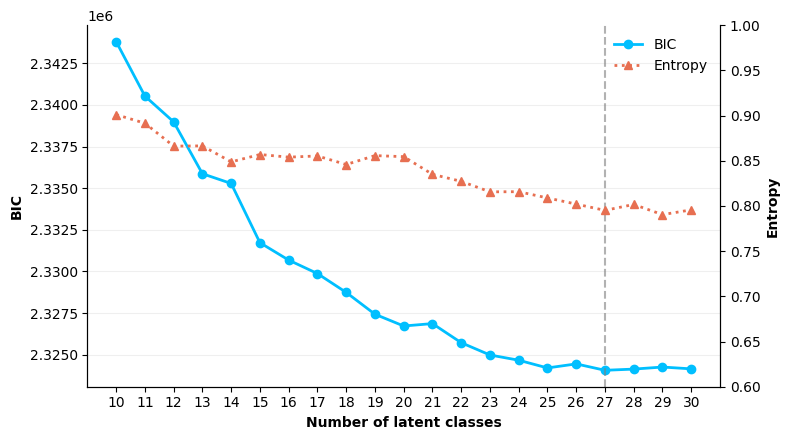

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(results_df["Classes"],
         results_df["BIC"],
         marker="o",
         markersize=6,
         linewidth=2,
         color="#00BFFF",
         label="BIC")

ax1.set_xlabel("Number of latent classes", fontweight="bold")
ax1.set_ylabel("BIC", fontweight="bold")

ax1.set_xticks(results_df["Classes"])

ax1.grid(axis="y", alpha=0.2)
ax1.spines["top"].set_visible(False)

ax2 = ax1.twinx()

ax2.plot(results_df["Classes"],
         results_df["Entropy"],
         marker="^",
         markersize=6,
         linewidth=2,
         linestyle=":",
         color="#E76F51",
         label="Entropy")

ax2.set_ylabel("Entropy", fontweight="bold")
ax2.set_ylim(0.6, 1.0)
ax2.spines["top"].set_visible(False)

ax1.axvline(27, linestyle="--", color="grey", alpha=0.6, linewidth=1.5)

lines = ax1.get_lines()[:1] + ax2.get_lines()
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="best", frameon=False)

plt.tight_layout()

plt.savefig("figures/lca_grid_search_model_selection.png", dpi=500, bbox_inches="tight")

plt.show()